# Báo cáo

Thông tin Nhóm 9:
- **Đào Việt Hoàng** — MSSV: *22127121*
- **Nguyễn Anh Khôi** — MSSV: *22127208*
- **Đặng Văn Kỳ** — MSSV: *22127227*

## 1. Bài toán

### Giới thiệu bài toán

Mục tiêu của bài toán lần này là sử dụng một mô hình Autoencoder có khả năng tự học các đặc trưng từ hình ảnh, sau đó sử dụng một mô hình phân loại đơn giản, thay vì sử dụng một mô hình phức tạp chỉ để phân loại. Quy trình này được thiết kế thành 2 mô hình:

- Autoencoder học cách để xây dựng đặc trưng ảnh thông qua cơ chế encode ảnh thành biểu diễn không gian ẩn, sau đó decode thành 1 ảnh tái tạo và so sánh ảnh tái tạo với ảnh gốc. Mục tiêu là học được cách để trích xuất các đặc trưng quan trọng. Đây là phần mà nhóm sẽ phải cài đặt không sử dụng thư viện, chỉ được dùng CUDA.

- Sử dụng SVM để học cách phân loại biểu diễn không gian ẩn của hình ảnh.

### Tổng quan bộ dữ liệu CIFAR10

Bao gồm 60000 ảnh RGB có kích thước 32x32, được chia thành 50000 mẫu train và 10000 mẫu test. Có tổng cộng 10 loại ảnh trong tập dữ liệu này. [Thông tin thêm tại đây.](https://www.cs.toronto.edu/~kriz/cifar.html)

![Screenshot from 2025-12-27 10-00-55.png](<attachment:Screenshot from 2025-12-27 10-00-55.png>)

### Pipeline

Quy trình diễn ra như sau:
1. Tải bộ dữ liệu CIFAR-10 lên máy và thực hiện tiền xử lý.
2. Huấn luyện Autoencoder để trích xuất đặc trưng của hình, chi tiết đã nói ở trên. Tiêu chí tối ưu là hàm MSE loss. Bước này không sử dụng label có sẵn của ảnh, mà sử dụng chính ảnh.
3. Sau khi huấn luyện Autoencoder xong, chỉ sử dụng chức năng encode để biến đổi ảnh thành biểu diễn không gian ẩn của nó.
4. Sử dụng SVM để phân loại biểu diễn ảnh, với label được lấy từ dữ liệu.
5. Đánh giá toàn bộ quy trình dựa trên tập test.

### Kiến trúc Autoencoder

Dưới đây là kiến trúc Autoencoder mà nhóm xây dựng:

Encoder:
```
INPUT: (32, 32, 3)
↓
Conv2D(256 filters, 3×3 kernel, padding=1, stride=1) + ReLU
→ (32, 32, 256)
↓
MaxPool2D(2×2, stride=2)
→ (16, 16, 256)
↓
Conv2D(128 filters, 3×3 kernel, padding=1, stride=1) + ReLU
→ (16, 16, 128)
↓
MaxPool2D(2×2, stride=2)
→ (8, 8, 128)
↓
LATENT REPRESENTATION: (8, 8, 128) = 1,024 dimensions
```

Decoder:
```
LATENT: (8, 8, 128)
↓
Conv2D(128 filters, 3×3 kernel, padding=1, stride=1) + ReLU
→ (8, 8, 128)
↓
UpSample2D(2×2) [Nearest neighbor]
→ (16, 16, 128)
↓
Conv2D(256 filters, 3×3 kernel, padding=1, stride=1) + ReLU
→ (16, 16, 256)
↓
UpSample2D(2×2) [Nearest neighbor]
→ (32, 32, 256)
↓
Conv2D(3 filters, 3×3 kernel, padding=1, stride=1) [No activation]
→ (32, 32, 3)
↓
OUTPUT: (32, 32, 3)
```

### Mục tiêu

Về mặt kỹ thuật:
- Thời gian huấn luyện: nhanh hơn ít nhất 30 lần so với thời gian huấn luyện CPU.
- Accuracy: MSE Loss trong quá trình huấn luyện Autoencoder dưới 0.05. Accuracy của quá trình phân loại (toàn bộ pipeline) đạt trên 60%.

Về mặt học tập: Học được cách thiết kế và lập trình thuật toán trên CUDA.
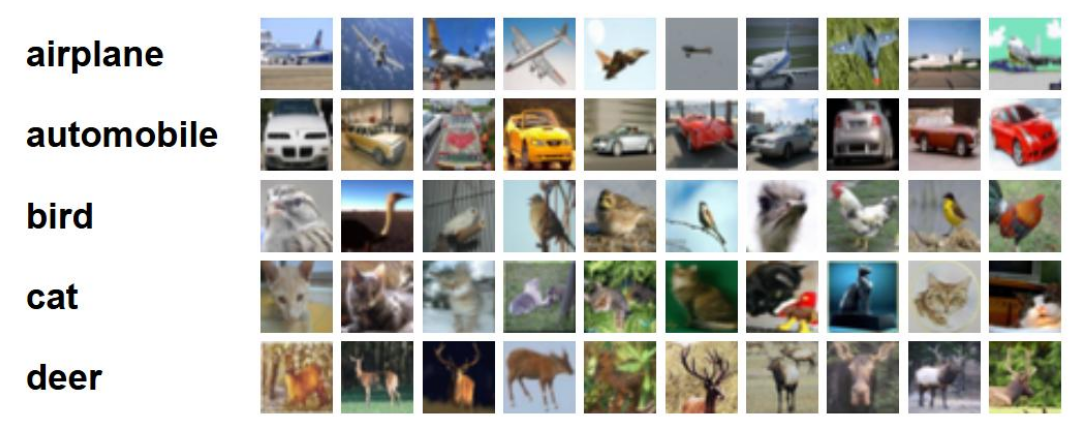

### Chuẩn bị

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!mkdir /content/drive/MyDrive/cuda_ltss/

Mount Google Drive để thuận tiện cho việc lưu trữ

Tải Nsight System

In [ ]:
# Here is the command to install Nsight system on Colab. You just need to run the cell.
!apt-get update
!apt-get install -y cuda-nsight-systems-12-2

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,205 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,556 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu j

Kiểm tra NVCC và NVIDIA driver

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [ ]:
!nvidia-smi

Fri Dec 19 14:18:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Clone repo trên GitHub và truy cập vào repo

In [ ]:
!git clone https://github.com/dvk26/cuda_ltss.git
%cd cuda_ltss/
!ls

fatal: destination path 'cuda_ltss' already exists and is not an empty directory.
/content/cuda_ltss
AGENTS.md			     ltss_gpu.ipynb	  Report.ipynb
autoencoder_gpu_v1_2		     ltss_gpu_v1_1.ipynb  report_name.nsys-rep
cifar-10-batches-bin		     ltss_gpu_v1_3.ipynb  report_name.sqlite
cifar-10-binary.tar.gz		     ltss_gpu_v1_4.ipynb  src
documents			     prompts		  train_svm.ipynb
extract_feature_and_train_svm.ipynb  README.md


Tải và giải nén dataset CIFAR-10

In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-binary.tar.gz
!tar -xvf cifar-10-binary.tar.gz

--2025-12-19 15:43:03--  https://www.cs.toronto.edu/~kriz/cifar-10-binary.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170052171 (162M) [application/x-gzip]
Saving to: ‘cifar-10-binary.tar.gz’

cifar-10-binary.tar 100%[===================>] 162.17M  31.3MB/s    in 5.7s    

2025-12-19 15:43:10 (28.2 MB/s) - ‘cifar-10-binary.tar.gz’ saved [170052171/170052171]

cifar-10-batches-bin/
cifar-10-batches-bin/data_batch_1.bin
cifar-10-batches-bin/batches.meta.txt
cifar-10-batches-bin/data_batch_3.bin
cifar-10-batches-bin/data_batch_4.bin
cifar-10-batches-bin/test_batch.bin
cifar-10-batches-bin/readme.html
cifar-10-batches-bin/data_batch_5.bin
cifar-10-batches-bin/data_batch_2.bin


## 2. Quá trình cài đặt

### Phase 1: CPU

#### Mục tiêu
- Xây dựng mạng autoencoder sử dụng toán tử convolution (convolutional autoencoder) bằng ngôn ngữ C chạy hoàn toàn trên CPU, chưa sử dụng CUDA, với vai trò là baseline implementation.


- Baseline implementation này sẽ có baseline runtime.


#### Cài đặt
- Một class Autoencoder trong C với các thuộc tính private là các layer, các phương thức public như encode, decode, forward, backward_and_update.
- Hàm main trong main.cpp để thiết lập các argument cho chương trình.


#### Biên dịch & chạy

Do thời gian chạy phiên bản CPU rất lâu (8 tiếng/epoch), chỉ 4% bộ dữ liệu (2000 mẫu train, 400 mẫu test) được giữ lại để debug cho các phiên bản GPU, giúp tiết kiệm thời gian.

Cách chạy:
1. Biên dịch chương trình:
```
!g++ -std=c++17 -O3 -march=native -ffast-math -DNDEBUG src/cpu/*.cpp -o autoencoder_cpu
```

2. Chạy chương trình:
```
!./autoencoder_cpu cifar-10-batches-bin [--keep-partial]
```
Trong đó, `--keep-partial` để sử dụng chỉ 4% dữ liệu.
Nếu không có flag này thì sử dụng toàn bộ dữ liệu.

3. Dữ liệu sẽ được đưa vào thư mục `out-cpu/`.

In [ ]:
# CPU version
!g++ -std=c++17 -O3 -march=native -ffast-math -DNDEBUG src/cpu/*.cpp -o autoencoder_cpu

In [ ]:
!./autoencoder_cpu cifar-10-batches-bin --keep-partial

In [ ]:
!cp -r ./out-cpu /content/drive/MyDrive/cuda_ltss/

#### Kết quả

| Thông số                     | Giá trị       |
|-----------------------------|---------------|
| Tổng số ảnh train           | 2,000 ảnh     |
| Tổng số ảnh test            | 400 ảnh       |
| Số lượng batch mỗi epoch    | 63 batches    |
| Kích thước batch (ước tính) | 32 ảnh/batch  |

- Train loss khởi tạo là 0.2666  
- Train loss của epoch cuối cùng là 0.0713  
- Test loss là 0.0745  
- <span style="color:red; font-weight:bold">Thời gian chạy trung bình: 1500 giây/epoch</span>

### Phase 2: Basic GPU

#### Mục tiêu

Nhận thấy trong quá trình tính toán, có rất nhiều phân đoạn có thể được song song hóa nhằm giảm thời gian; chẳng hạn như thao tác convolution cho mỗi output pixel không ảnh hưởng đến input của các thao tác convolution khác. Quá trình đưa từ CPU lên GPU trong giai đoạn này chỉ đóng vai trò song song hóa những phân đoạn có thể thực hiện đồng thời. Ngoài ra, phiên bản GPU cơ bản này còn đóng vai trò làm baseline cho các phiên bản GPU cải tiến về sau.

#### Cài đặt

**Thiết kế layer**

Mỗi layer sẽ bao gồm 2 kernel phục vụ cho việc forward và backward.

1. Convolution: Đối với forward, việc tính tích chập cho 27 phần tử (9 phần tử /input channel * 3 input channels) được song song hóa, giúp giảm đến 4 vòng lặp for dành cho output channel (theo chiều dài - chiều rộng - out channel - từng mẫu trong batch). Còn ở backward thì cập nhật 27 trọng số của từng kernel cùng 1 lúc.

2. ReLU: Layer này là element-wise, nên chỉ cần thực hiện cho từng phần tử trên input là được. Áp dụng trên cả forward và backward.

3. Pooling: Tác vụ lấy max cho mỗi 4 phần tử được thực hiện song song.

4. Upsample: Thực hiện quá trình upsample theo kỹ thuật nearest neighbor. Việc lấy mẫu trên 4 pixel xung quanh được thực hiện cùng một lúc trên tất cả các channel và trên tất cả các mẫu trong batch. Đối với backward, chỉ cần cộng dồn ngược là xong do Upsample vốn không có tham số.

Quản lý bộ nhớ: Bộ nhớ được sử dụng bao gồm trọng số, kết quả của các layer và đạo hàm cho mỗi layer.

**Thiết kế của lớp GPUAutoencoder**

Các phương thức bên trong lớp `GPUAutoencoder`:
- `encode()`: Thực hiện quá trình encode: Conv1 -> ReLU1 -> Pool1 -> Conv2 -> ReLU2 -> Pool2
- `decode()`: Thực hiện quá trình decode: Conv3 -> ReLU3 -> Upsample1 -> Conv4 -> ReLU4 -> Upsample2 -> Conv5
- `forward()`: Thực hiện quá trình encode và decode cùng lúc
- `backward_and_update()`: Thực hiện quá trình backpropagation và cập nhật tham số cùng 1 lúc
- `save_weights()`: Lưu trọng số xuống ổ nhớ

#### Biên dịch & chạy

In [ ]:
# GPU version
!nvcc -std=c++17 -O2 \
    src/gpu_v1.1/main.cu \
    src/gpu_v1.1/gpu_autoencoder.cu \
    -I./src/gpu_v1.1 \
    -arch=sm_75 \
    -o gpu-autoencoder-v1-1

In [ ]:
!./gpu-autoencoder-v1-1 cifar-10-batches-bin

#### Kết quả & Profiling

*Profiling được thực hiện chỉ trên 1 epoch để thuận tiện cho việc theo dõi.*

- Thời gian chạy của mỗi epoch là khoảng 570 giây; tổng thời gian chạy là 180 phút (3 tiếng)
- Tăng tốc hơn rất nhiều so với phiên bản CPU (theo dự tính, mất tới 8 tiếng cho 1 epoch).
- MSE loss cũng rất thấp, chỉ rơi vào khoảng 0.01.

Đây là một bước cải tiến vô cùng lớn so với phiên bản CPU, cho thấy tiềm năng cải tiến xa hơn nữa.

Dung lượng GMEM chương trình sử dụng: 0.7GB.

In [ ]:
# Bước 1: Thu thập Timeline và Memory Usage Sampling
!nsys profile --trace=cuda,nvtx,osrt \
              --cuda-memory-usage=true \
              --stats=true \
              -o report_name \
              ./gpu-autoencoder-v1-1 cifar-10-batches-bin --one-epoch

Loading CIFAR-10...
Total images: 60000 (train 50000, test 10000)
[Epoch 1/1] Batch 780/782 | Loss: 0.0480
=== Epoch 1 | train_loss=0.0480 | time=589.0349s ===

=== Final Test Evaluation ===
Final test_loss=0.0285
Done. Check ./out-gpu/*.bin for weights.
Generating '/tmp/nsys-report-4c2f.qdstrm'
[1/8] [========================100%] report_name.nsys-rep
[2/8] [========================100%] report_name.sqlite
[3/8] Executing 'nvtx_sum' stats report
SKIPPED: /content/cuda_ltss/report_name.sqlite does not contain NV Tools Extension (NVTX) data.
[4/8] Executing 'osrt_sum' stats report

 Time (%)  Total Time (ns)  Num Calls    Avg (ns)      Med (ns)     Min (ns)   Max (ns)    StdDev (ns)           Name         
 --------  ---------------  ---------  ------------  -------------  --------  -----------  -----------  ----------------------
    100.0  595,470,790,897      5,982  99,543,763.1  100,139,912.0       520  275,879,616  8,472,972.3  poll                  
      0.0      177,120,450     

**Thống kê CUDA API**

| Name                   | Time (%) | Total Time (ns) | Num Calls |      Avg (ns) |
| ---------------------- | -------- | --------------- | --------: | ------------: |
| cudaDeviceSynchronize  | 99.7     | 593,602,785,735 |     2,655 | 223,579,203.7 |
| cudaMemcpy             | 0.2      | 960,239,054     |     7,360 |     130,467.3 |
| cudaLaunchKernel       | 0.1      | 318,765,257     |    49,825 |       6,397.7 |
| cudaMalloc             | 0.0      | 98,974,281      |        52 |   1,903,351.6 |
| cudaFree               | 0.0      | 85,685,391      |        52 |   1,647,796.0 |
| cudaDeviceReset        | 0.0      | 62,896,683      |         1 |  62,896,683.0 |
| cudaMemset             | 0.0      | 11,976,466      |       937 |      12,781.7 |
| cuCtxSynchronize       | 0.0      | 8,477           |         1 |       8,477.0 |
| cuModuleGetLoadingMode | 0.0      | 1,643           |         1 |       1,643.0 |

**Thống kê GPU Kernel**

| Kernel                     | Time (%) | Total Time (ns) | Instances |      Avg (ns) |
| -------------------------- | -------- | --------------- | --------: | ------------: |
| conv2d_backward_kernel     | 94.5     | 560,915,327,946 |     3,905 | 143,640,288.8 |
| conv2d_forward_kernel      | 4.7      | 27,918,837,733  |     4,685 |   5,959,197.0 |
| zero_kernel                | 0.2      | 968,766,277     |    18,744 |      51,684.1 |
| relu_backward_kernel       | 0.1      | 803,156,818     |     3,124 |     257,092.5 |
| relu_forward_kernel        | 0.1      | 705,249,602     |     3,748 |     188,166.9 |
| upsample2x_forward_kernel  | 0.1      | 515,952,285     |     1,874 |     275,321.4 |
| maxpool2x2_backward_kernel | 0.1      | 515,014,301     |     1,562 |     329,714.7 |
| mse_loss_kernel            | 0.1      | 455,295,596     |       937 |     485,907.8 |
| maxpool2x2_forward_kernel  | 0.1      | 415,980,784     |     1,874 |     221,974.8 |
| upsample2x_backward_kernel | 0.0      | 283,001,463     |     1,562 |     181,178.9 |
| sgd_update_kernel          | 0.0      | 31,676,299      |     7,810 |       4,055.9 |

**Thống kê GPU Memory Time**

| Operation        | Time (%) | Total Time (ns) | Count |  Avg (ns) |
| ---------------- | -------- | --------------- | ----: | --------: |
| CUDA memcpy DtoD | 85.4     | 722,426,790     | 4,529 | 159,511.3 |
| CUDA memcpy HtoD | 7.4      | 62,663,433      |   947 |  66,170.5 |
| CUDA memcpy DtoH | 7.1      | 59,969,854      | 1,884 |  31,831.1 |
| CUDA memset      | 0.1      | 432,626         |   937 |     461.7 |


**Thống kê GPU Memory Size**

| Operation        | Total (MB) | Count | Avg (MB) | Med (MB) | Min (MB) | Max (MB) | StdDev (MB) |
| ---------------- | ---------: | ----: | -------: | -------: | -------: | -------: | ----------: |
| CUDA memcpy DtoD | 89,040.617 | 4,529 |   19.660 |    8.389 |    0.786 |   67.109 |      24.883 |
| CUDA memcpy DtoH |    739.898 | 1,884 |    0.393 |    0.014 |    0.000 |    1.180 |       0.394 |
| CUDA memcpy HtoD |    739.894 |   947 |    0.781 |    0.786 |    0.000 |    1.180 |       0.069 |
| CUDA memset      |      0.004 |   937 |    0.000 |    0.000 |    0.000 |    0.000 |       0.000 |




**Phân tích**

1. Phân tích Bottleneck

Nhìn vào bảng `cuda_gpu_kern_sum`, nhận thấy một sự mất cân bằng khủng khiếp: `conv2d_backward_kernel` chiếm 94.5% tổng thời gian chạy GPU. Thời gian trung bình (`Avg`) của nó lên tới 143ms/lần gọi, trong khi kernel forward chỉ tốn 5.9ms.  Logic tính toán hoặc cách truy cập bộ nhớ trong phần tính Gradient đang gặp vấn đề cực lớn.

2. Basic Profiling (Hiệu năng hệ thống)

Nhìn vào bảng `cuda_api_sum`, `cudaDeviceSynchronize` chiếm 99.7% thời gian API. Điều này cho thấy CPU đang phải "ngồi chơi xơi nước" để đợi GPU hoàn thành xong kernel `backward`. Chương trình đang chạy theo kiểu synchronous, không có sự overlap giữa tính toán và truyền dữ liệu.

3. GPU Memory Usage & Bandwidth

Bảng `cuda_gpu_mem_size_sum` cho thấy tổng lượng dữ liệu DtoD (Device to Device) lên tới 89GB, trong khi dữ liệu nạp vào (HtoD) chỉ có ~740MB, việc copy nội bộ trên GPU (DtoD) lại lớn gấp 120 lần. Chương trình đang lạm dụng `cudaMemcpyDtoD` hoặc các thao tác gán mảng trong vòng lặp training. Việc di chuyển dữ liệu qua lại trong VRAM quá nhiều đang "đốt" băng thông bộ nhớ của bạn vô ích.

4. Memory Bandwidth Utilization

Dù bảng này không hiện % băng thông cụ thể (phải dùng `ncu` mới thấy), nhưng ta có thể tính toán sơ bộ: `cudaMemcpyDtoD` tốn 722ms cho 89GB, suy ra tốc độ thực tế là 89GB / 0.722s = 123GB/s.






### Phase 3: 1st Optimized GPU (Kỳ)

#### Mục tiêu
Đã triển khai phiên bản GPU của autoencoder bằng CUDA, tối ưu hoá các kernel cốt lõi bằng shared memory và kernel fusion. Các tối ưu này giảm đáng kể truy cập bộ nhớ toàn cục và số lần đọc/ghi trung gian, từ đó cải thiện throughput và giảm thời gian huấn luyện/tiền xử lý.

#### Cài đặt
Autoencoder được triển khai trên GPU bằng CUDA nhằm tăng hiệu năng tính toán. Các bước tính toán chính (forward, backward và các phép toán ma trận) được chuyển từ CPU sang các kernel CUDA và toàn bộ dữ liệu được giữ trên device memory trong suốt pipeline để giảm chi phí truyền dữ liệu giữa CPU và GPU.

Để tối ưu hiệu năng, hai kỹ thuật chính được áp dụng:

(1) Shared memory tiling.
Các kernel tính toán sử dụng shared memory để lưu các tile con của ma trận/feature maps trong quá trình nhân ma trận và các phép toán tương tự convolution. Việc này giúp giảm số lần truy cập global memory và tăng khả năng tái sử dụng dữ liệu. Kích thước tile và số threads mỗi block được lựa chọn nhằm cân bằng giữa occupancy và lượng shared memory sử dụng. Đồng bộ hoá giữa các thread trong block được thực hiện bằng __syncthreads() để đảm bảo tính đúng đắn và tránh race condition; đồng thời chú ý hạn chế bank conflicts trong shared memory.

(2) Kernel fusion.
Các bước xử lý liên tiếp như nhân ma trận, cộng bias và hàm kích hoạt được gộp vào cùng một kernel. Cách tiếp cận này loại bỏ các phép ghi/đọc trung gian ra global memory và giảm overhead do nhiều lần kernel launch. Khi áp dụng kernel fusion, việc sử dụng thanh ghi (register pressure) được cân nhắc để tránh làm giảm occupancy của GPU.

Ngoài ra, dữ liệu được tổ chức lại theo hướng memory coalescing để các thread trong cùng warp truy cập các vùng nhớ liên tiếp. Các tham số biên dịch và cấu hình kernel (threads/block, shared memory per block) được tinh chỉnh nhằm đạt hiệu năng tốt nhất trong khi vẫn đảm bảo tính ổn định số học.

#### Biên dịch & chạy

In [12]:
# GPU version 1.4
!nvcc -std=c++17 -O2 \
    src/gpu_v1.3/main.cu \
    src/gpu_v1.3/gpu_autoencoder.cu \
    -I./src/gpu_v1.3 \
    -arch=sm_75 \
    -o autoencoder_gpu_v1_2

In [ ]:
!./autoencoder_gpu cifar-10-batches-bin --keep-partial

#### Kết quả & Profiling

In [13]:
!nsys profile --trace=cuda,nvtx,osrt \
              --cuda-memory-usage=true \
              --stats=true \
              -o report_name \
              ./autoencoder_gpu_v1_2 cifar-10-batches-bin

Loading CIFAR-10...
Total images: 60000 (train 50000, test 10000)
Starting training v1.2 (Full GPU Pipeline)...
[Epoch 1/1] Batch 780/782 | Loss: 0.0480
   -> Time: 555.5260s (1.4 batches/s)

=== Final Test Evaluation ===
Final Test MSE Loss: 0.0
Done. Check ./out-gpu-v1.4 for weights.
Generating '/tmp/nsys-report-1409.qdstrm'
Failed to create '/content/cuda_ltss/report_name.nsys-rep': File exists.
Use `--force-overwrite true` to overwrite existing files.
[1/8] [========================100%] nsys-report-3e92.nsys-rep
Failed to create '/content/cuda_ltss/report_name.sqlite': File exists.
Use `--force-overwrite true` to overwrite existing files.
[2/8] [========================100%] nsys-report-9b66.sqlite
[3/8] Executing 'nvtx_sum' stats report
SKIPPED: /tmp/nsys-report-9b66.sqlite does not contain NV Tools Extension (NVTX) data.
[4/8] Executing 'osrt_sum' stats report

 Time (%)  Total Time (ns)  Num Calls    Avg (ns)      Med (ns)     Min (ns)   Max (ns)    StdDev (ns)           Name  

**Thống kê CUDA API**

| Name                   | Time (%) | Total Time (ns) | Num Calls | Avg (ns)      |
| ---------------------- | -------- | --------------- | --------- | ------------- |
| cudaDeviceSynchronize  | 99.9     | 562,930,741,956 | 1,718     | 327,666,322.4 |
| cudaLaunchKernel       | 0.1      | 290,781,252     | 49,201    | 5,910.1       |
| cudaMemcpy             | 0.0      | 280,169,554     | 6,423     | 43,619.7      |
| cudaMalloc             | 0.0      | 95,616,355      | 52        | 1,838,776.1   |
| cudaFree               | 0.0      | 70,457,455      | 52        | 1,354,951.1   |
| cudaDeviceReset        | 0.0      | 54,129,410      | 1         | 54,129,410.0  |
| cudaMemset             | 0.0      | 21,682,456      | 937       | 23,140.3      |
| cuCtxSynchronize       | 0.0      | 9,863           | 1         | 9,863.0       |
| cuModuleGetLoadingMode | 0.0      | 1,643           | 1         | 1,643.0       |

**Thống kê GPU Kernel**

| Kernel                            | Time (%) | Total Time (ns) | Instances |      Avg (ns) |
| --------------------------------- | -------- | --------------- | --------: | ------------: |
| conv2d_backward_filter_kernel     | 84.5     | 475,350,684,767 |     3,905 | 121,728,728.5 |
| conv2d_relu_forward_tiled_kernel  | 7.5      | 42,327,289,630  |     3,748 |  11,293,300.3 |
| conv2d_backward_data_tiled_kernel | 7.0      | 39,118,079,526  |     3,905 |  10,017,433.9 |
| conv2d_forward_tiled_kernel       | 0.4      | 2,094,375,884   |       937 |   2,235,193.0 |
| zero_kernel                       | 0.2      | 964,834,960     |    17,963 |      53,712.4 |
| relu_backward_kernel              | 0.1      | 803,080,096     |     3,124 |     257,067.9 |
| maxpool2x2_backward_kernel        | 0.1      | 509,805,556     |     1,562 |     326,380.0 |
| upsample2x_forward_kernel         | 0.1      | 496,003,158     |     1,874 |     264,676.2 |
| maxpool2x2_forward_kernel         | 0.1      | 416,563,361     |     1,874 |     222,285.7 |
| upsample2x_backward_kernel        | 0.0      | 275,596,001     |     1,562 |     176,437.9 |
| sgd_update_kernel                 | 0.0      | 31,391,079      |     7,810 |       4,019.3 |
| mse_loss_kernel                   | 0.0      | 12,199,970      |       937 |      13,020.2 |


**Thống kê GPU Memory Time**

| Operation        | Time (%) | Total Time (ns) | Count | Avg (ns)  |
| ---------------- | -------- | --------------- | ----- | --------- |
| CUDA memcpy DtoD | 91.7     | 719,684,453     | 4,529 | 158,905.8 |
| CUDA memcpy HtoD | 8.0      | 62,562,675      | 947   | 66,064.1  |
| CUDA memcpy DtoH | 0.2      | 1,849,271       | 947   | 1,952.8   |
| CUDA memset      | 0.1      | 402,460         | 937   | 429.5     |


**Thống kê GPU Memory Size**

| Operation        | Total (MB) | Count | Avg (MB) | Med (MB) | Min (MB) | Max (MB) | StdDev (MB) |
| ---------------- | ---------- | ----- | -------- | -------- | -------- | -------- | ----------- |
| CUDA memcpy DtoD | 89,040.617 | 4,529 | 19.660   | 8.389    | 0.786    | 67.109   | 24.883      |
| CUDA memcpy HtoD | 739.894    | 947   | 0.781    | 0.786    | 0.000    | 1.180    | 0.069       |
| CUDA memcpy DtoH | 3.011      | 947   | 0.003    | 0.000    | 0.000    | 1.180    | 0.057       |
| CUDA memset      | 0.004      | 937   | 0.000    | 0.000    | 0.000    | 0.000    | 0.000       |

**Phân tích**

- Thời gian tổng bị chặn (poll / cudaDeviceSynchronize): hầu hết thời gian wall (~563 s) nằm trong poll và cudaDeviceSynchronize. Điều này cho thấy chương trình thường xuyên chờ đồng bộ (synchronization) hoặc có nhiều khoảng chờ giữa CPU ↔ GPU — giảm được các cudaDeviceSynchronize().

- Hotspot kernel chính: conv2d_backward_filter_kernel chiếm ~84.5% thời gian GPU-kernel. Đây là kernel cần tập trung tối ưu (tiling, shared memory, giảm work, hoặc thay bằng cuDNN/cuBLAS nếu hợp lý).

- Các kernel khác đáng chú ý: conv2d_relu_forward_tiled_kernel và conv2d_backward_data_tiled_kernel cũng tiêu tốn đáng kể (~7–8% mỗi kernel) — tức là workload chủ yếu là backward (gradient) của convs.
- Host↔Device (HtoD / DtoH) nhỏ: tổng HtoD ~740 MB, DtoH ~3 MB — input/output không là nút thắt lớn, vấn đề nằm trong nội bộ GPU.

- Số lần kernel launch lớn nhưng mỗi lần nhỏ: nhiều cudaLaunchKernel (49k calls) với thời gian trung bình nhỏ → launch overhead + nhiều sync có thể cộng lại gây chậm. Cân nhắc gộp (fusion) các bước nhỏ vào ít kernel lớn hơn.

- Memset / malloc / free: có các cudaMalloc/cudaFree tốn thời gian (tổng đáng kể khi chạy nhiều lần). Nếu có thể, allocate once và reuse buffers qua toàn training.

**Nhận xét**
- Mặc dù phần lớn thời gian GPU kernel tập trung vào `conv2d_backward_filter_kernel` (84.5% kernel time),
tổng thời gian thực thi lại bị chi phối bởi `cudaDeviceSynchronize` (~99.9% CUDA API time),
cho thấy pipeline huấn luyện còn đồng bộ hóa quá thường xuyên giữa CPU và GPU.

- Điều này khiến CPU phải chờ GPU hoàn thành từng bước thay vì cho phép chồng chéo (overlap)
giữa kernel execution và các thao tác điều khiển, dẫn đến thời gian huấn luyện tổng thể vẫn lớn
dù các kernel riêng lẻ đã được tối ưu bằng tiling và fusion.


### Phase 4: 2nd Optimized GPU

#### Mục tiêu

* Đánh đổi một phần **độ chính xác số học** trong quá trình tính toán và **thời gian tính toán** để đổi lấy VRAM. Giúp tăng được batch size lên rất nhiều lần trong tương lai.
* Sử dụng **mixed precision training** (FP16 để tính toán activations và FP32 để lưu weight và tích luỹ gradient).
* Sử dụng **memory aliasing** để tiết kiệm VRAM.
* Sử dụng **manual gradient checkpointing** tại cuối mỗi epoch để tiết kiệm VRAM.

#### Cài đặt
* Ta lưu master weight ở biểu diễn FP32 và lưu các feature map ở biểu diễn FP16 để tận dụng sức mạnh tính toán của các Tensor Core.
* Dùng 2 kernel `fp32_to_fp16_kernel` với `fp16_to_fp32_kernel` để chuyển đổi qua lại dữa 2 biểu diễn khi cần.
* Ta dùng 2 vùng nhớ (buffer) với tổng kích thước $2 \times S_\text{max}$ để lưu gradient đầu ra và đầu vào của mỗi layer (gọi là các gradient trung gian). Trong đó, $S_\text{max}$ là kích thước của layer lớn nhất - là input layer của encoder 1 và output layer của decoder 2 - với khoảng $128 \times 256 \times 32 \times 32 = 33,554,432$ phần tử. Mỗi phần tử tương ứng 4 bytes thì tổng dung lượng VRAM của 2 buffer này là $2 \times 33,554,432 \times 4$ bytes  $= 2 \times 128$ MiB $= 256$ MiB.
  * Chi tiết cài đặt như sau: Ta sẽ khai báo 2 con trỏ (`d_grad_pool_a_` và `d_grad_pool_b_`) trỏ đến 2 vùng nhớ buffer, mỗi vùng có 128MiB. Các con trỏ gradient sẽ lần lượt trỏ đến 2 buffer này.

  ```
  // [v1.4] Memory aliasing for intermediate feature-map gradients:
  // We only ever need two live gradients at a time in `backward_compute_gradients()`,
  // so we allocate two pools (A/B) and alias the named gradient pointers onto them.
  grad_pool_elems_ = std::max({
      nchw_size(N_, 256, H_,  W_),   // du2, dr1, dc1
      nchw_size(N_, 256, H1_, W1_),  // dr4, dc4, dp1
      nchw_size(N_, 128, H1_, W1_),  // du1, dc2, dr2
      nchw_size(N_, 128, H2_, W2_),  // dr3, dc3, dp2
      nchw_size(N_, 3,   H_,  W_)    // dc5, dx
  });
  CUDA_CHECK(cudaMalloc(&d_grad_pool_a_, grad_pool_elems_ * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&d_grad_pool_b_, grad_pool_elems_ * sizeof(float)));
  ```

  ```
  // Gradient flow contract (ping-pong):
  // dc5(A) -> du2(B) -> dr4(A) -> dc4(B) -> du1(A) -> dr3(B) -> dc3(A)
  //     -> dp2(B) -> dr2(A) -> dc2(B) -> dp1(A) -> dr1(B) -> dc1(A) -> dx(B)
  d_dc5_ = d_grad_pool_a_;
  d_du2_ = d_grad_pool_b_;
  d_dr4_ = d_grad_pool_a_;
  d_dc4_ = d_grad_pool_b_;
  d_du1_ = d_grad_pool_a_;
  d_dr3_ = d_grad_pool_b_;
  d_dc3_ = d_grad_pool_a_;
  d_dp2_ = d_grad_pool_b_;
  d_dr2_ = d_grad_pool_a_;
  d_dc2_ = d_grad_pool_b_;
  d_dp1_ = d_grad_pool_a_;
  d_dr1_ = d_grad_pool_b_;
  d_dc1_ = d_grad_pool_a_;
  d_dx_  = d_grad_pool_b_;
  ```
* Ta chỉ lưu lại các giá trị activation của lớp pooling thứ 2 trong mạng (output của encoder phase), các giá trị activation trung gian khác sẽ được xoá đi hết. Khi tính toán backward pass, kernel `forward_decoder_from_p2` sẽ được gọi để tính lại khi cần.

#### Biên dịch & chạy

In [ ]:
!git checkout anhkhoi-branch

In [ ]:
# Compile GPU version 1.4
!nvcc -std=c++17 -O2 \
    src/gpu_v1.4/main.cu \
    src/gpu_v1.4/gpu_autoencoder.cu \
    -I./src/gpu_v1.4 \
    -arch=sm_75 \
    -o autoencoder_gpu_v1_4_tesla_t4

In [ ]:
# Batch size 64
!./autoencoder_gpu_v1_4_tesla_t4 cifar-10-batches-bin --keep-partial

#### Kết quả & Profiling

In [ ]:
# Batch size 128
!nvcc -std=c++17 -O2 -g -lineinfo \
    src/gpu_v1.4/main.cu \
    src/gpu_v1.4/gpu_autoencoder.cu \
    -I./src/gpu_v1.4 \
    -arch=sm_75 \
    -o autoencoder_gpu_v1_4_tesla_t4

In [ ]:
!nsys profile -o  profile_v1_4 --stats=true ./autoencoder_gpu_v1_4_tesla_t4 cifar-10-batches-bin --keep-partial

**Tổng quan**

| Chỉ số (Metric)                  | v1.3 (FP32 Standard) | v1.4 (Mixed Precision) | v1.4 (Mixed Precision) |
|----------------------------------|----------------------|------------------------|------------------------|
| Batch Size                       | 64                   | 64                     | 128                    |
| Initial Train Loss (Epoch 1)     | 0.1975               | 0.1983                 | 0.3118                 |
| Final Train Loss (Epoch 20)      | 0.0313               | 0.0313                 | 0.0416                 |
| Final Test Loss                  | 0.00*                | 0.03                   | 0.04                   |
| Thời gian trung bình / Epoch     | ~22.0s               | ~23.6s                 | ~22.7s                 |
| Throughput (Images/s)            | 89.6                 | 83.2                   | 89.6                   |
| Peak VRAM Usage                  | N/A                  | 456.94 MiB             | 516.94 MiB             |

**Tỉ trọng thời gian chạy của các kernel**
| Time (%) | Total Time (ns) | Instances | Avg (ns)       | Med (ns)       | Min (ns)   | Max (ns)     | StdDev (ns)   | Name |
|---------:|----------------:|----------:|---------------:|---------------:|-----------:|-------------:|--------------:|------|
| 50.2 | 97,240,285,823 | 1,500 | 64,826,857.2 | 18,010,748.0 | 10,268,742 | 155,125,119 | 62,219,457.2 | conv2d_backward_filter_partial_fp16x |
| 30.6 | 59,255,358,084 | 2,412 | 24,566,898.0 | 26,442,999.5 | 4,210,190 | 89,355,005 | 17,769,019.8 | conv2d_relu_forward_tiled_kernel_fp16io |
| 16.2 | 31,490,544,103 | 1,500 | 20,993,696.1 | 11,304,108.5 | 3,679,925 | 49,761,322 | 17,793,333.9 | conv2d_backward_data_tiled_kernel |
| 1.3 | 2,588,825,927 | 603 | 4,293,243.7 | 4,311,009.0 | 3,877,202 | 8,237,726 | 258,375.0 | conv2d_forward_tiled_kernel_fp16in_fp32out |
| 0.4 | 818,057,873 | 1,500 | 545,371.9 | 266,555.5 | 104,863 | 1,924,799 | 595,899.0 | conv2d_backward_bias_partial |
| 0.3 | 610,242,095 | 1,206 | 506,005.1 | 506,985.5 | 105,182 | 1,510,766 | 391,056.2 | upsample2x_forward_kernel_fp16 |
| 0.3 | 560,332,169 | 1,200 | 466,943.5 | 244,476.5 | 42,111 | 1,404,487 | 511,064.4 | relu_backward_kernel_fp16y |
| 0.2 | 397,109,379 | 600 | 661,849.0 | 656,453.0 | 142,782 | 1,197,586 | 515,822.5 | maxpool2x2_backward_kernel |
| 0.2 | 319,951,011 | 1,206 | 265,299.3 | 269,420.0 | 55,359 | 556,761 | 209,563.1 | maxpool2x2_forward_kernel_fp16 |
| 0.1 | 209,553,926 | 600 | 349,256.5 | 348,330.5 | 80,191 | 621,497 | 268,766.4 | upsample2x_backward_kernel |
| 0.1 | 197,981,813 | 3,600 | 54,994.9 | 1,440.0 | 1,024 | 600,057 | 156,316.4 | zero_kernel |
| 0.1 | 107,811,720 | 1,500 | 71,874.5 | 19,936.0 | 15,359 | 154,942 | 66,726.4 | reduce_filter_partials_kernel |
| 0.0 | 12,557,826 | 3,000 | 4,185.9 | 1,952.0 | 1,536 | 14,592 | 4,006.3 | sgd_update_kernel |
| 0.0 | 9,887,571 | 3,000 | 3,295.9 | 1,824.0 | 1,376 | 8,864 | 2,511.9 | check_nonfinite_kernel |
| 0.0 | 7,009,241 | 303 | 23,132.8 | 23,232.0 | 20,959 | 42,080 | 1,513.4 | mse_loss_kernel |
| 0.0 | 6,570,564 | 1,500 | 4,380.4 | 3,712.0 | 2,368 | 9,152 | 1,893.2 | reduce_bias_partials_kernel |
| 0.0 | 4,222,901 | 303 | 13,937.0 | 14,208.0 | 7,200 | 18,176 | 1,726.1 | fp32_to_fp16_kernel |
| 0.0 | 451,541 | 300 | 1,505.1 | 1,536.0 | 1,280 | 1,728 | 103.3 | clear_int_kernel |

**Tỉ trọng các thao tác chuyển data**
| Time (%) | Total Time (ns) | Count | Avg (ns) | Med (ns) | Min (ns) | Max (ns) | StdDev (ns) | Operation |
|---------:|----------------:|------:|---------:|---------:|---------:|---------:|------------:|-----------|
| 84.1 | 40,280,526 | 313 | 128,691.8 | 130,719.0 | 640 | 188,700 | 20,545.1 | [CUDA memcpy HtoD] |
| 12.5 | 5,979,244 | 803 | 7,446.1 | 1,664.0 | 1,280 | 104,703 | 20,950.7 | [CUDA memcpy DtoH] |
| 2.8 | 1,319,181 | 300 | 4,397.3 | 4,416.0 | 3,968 | 8,607 | 326.2 | [CUDA memcpy DtoD] |
| 0.6 | 301,375 | 303 | 994.6 | 1,088.0 | 384 | 1,728 | 260.2 | [CUDA memset] |

**Thống kê dung lượng GPU memory**
| Total (MB) | Count | Avg (MB) | Med (MB) | Min (MB) | Max (MB) | StdDev (MB) | Operation |
|-----------:|------:|---------:|---------:|---------:|---------:|------------:|-----------|
| 479.585 | 313 | 1.532 | 1.573 | 0.000 | 1.573 | 0.239 | [CUDA memcpy HtoD] |
| 471.859 | 300 | 1.573 | 1.573 | 1.573 | 1.573 | 0.000 | [CUDA memcpy DtoD] |
| 60.152 | 803 | 0.075 | 0.000 | 0.000 | 1.180 | 0.269 | [CUDA memcpy DtoH] |
| 0.001 | 303 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | [CUDA memset] |

**Nhận xét nhanh**
- Các kernel chính của convolutional model vẫn chiếm tỉ trọng lớn thời gian tính toán chứ không phải các kernel khác. Tuy nhiên vẫn có thể cải thiện thêm.
- Việc chuyển dữ liệu từ host sang device vẫn chiếm tỉ trọng lớn trong tổng thời gian chuyển dữ liệu.
- Với batch size từ 64 ảnh một batch lên 128 ảnh 1 batch và peak VRAM từ 456.94 MiB lên 516.94 MiB chứng tỏ VRAM được tiết kiệm tốt.

### Phase 5: Train SVM

- Trích xuất đặc trưng vào file train.bin và test.bin để tiến hành cho việc huấn luyện SVM

In [14]:
!nvcc -std=c++17 -O3 \
    src/extract_feature/extract_features_to_file.cpp \
    src/extract_feature/gpu_autoencoder.cu \
    -I./include \
    -arch=sm_75 \
    --default-stream per-thread \
    -o extract_feature

In [15]:
!./extract_feature cifar-10-batches-bin src/weights/weights_gpu_v1_3.bin

Loading dataset...
Successfully loaded weights from src/weights/weights_gpu_v1_3.bin
Weights loaded successfully.
Saving to train_features.bin...

Done! Saved 49984 samples to train_features.bin (19.23s)
Saving to test_features.bin...

Done! Saved 9984 samples to test_features.bin (3.84s)

All features extracted successfully. Ready for Python/cuML!


- Tiến hành train mô hình SVM

In [16]:
%cd src/train_svm_cuml/

/content/cuda_ltss/src/train_svm_cuml


In [17]:
!python train_svm.py

Loading ../../train_features.bin...
  Samples: 49984, Dim: 8192
Loading ../../test_features.bin...
  Samples: 9984, Dim: 8192
Training cuML SVM...
Test Accuracy: 68.85%
^C


## 3. Phân tích hiệu suất

So sánh giữa các phiên bản với nhau

| Phase | Training time | Speedup vs CPU | Incremental speedup | Memory usage | Key optimization |
| - | - | - | - | - | - |
| CPU Baseline | 8h / epoch | 1x | - | - | - |
| GPU Basic | 590s / epoch | 48x | 48x | 740MB | Song song hóa cơ bản |
| GPU Optimized v1 | 550s / epoch | 53x | 1.07x | 740MB | Shared memory tiling, Kernel fusion |
| GPU Optimized v2 | 567s / epoch | 51x | 0.9x | 740MB | Mixed precision training, Memory aliasing |

## 4. Kinh nghiệm rút ra
1. Thách thức 1: Thời gian chạy GPU quá lớn ở bước backward của convolution

+ Vấn đề: Profiling cho thấy kernel tính gradient convolution chiếm phần lớn thời gian thực thi.

+ Giải pháp: Phân tích kernel bằng Nsight Compute và tối ưu việc tái sử dụng dữ liệu thông qua shared memory, đồng thời giảm các sao chép bộ nhớ không cần thiết.

**Bài học**: Tối ưu đúng kernel “nóng” nhất mang lại cải thiện hiệu năng rõ rệt.

2. Thách thức 2: Đồng bộ CPU–GPU và kernel launch quá nhiều

+ Vấn đề: Nhiều lần gọi cudaDeviceSynchronize() và nhiều kernel nhỏ làm GPU không được sử dụng hiệu quả.

+ Giải pháp: Giảm các điểm đồng bộ và áp dụng kernel fusion để gộp nhiều bước xử lý vào một kernel.

**Bài học**: Hạn chế đồng bộ và giảm số kernel launch là yếu tố then chốt để tăng hiệu năng GPU.

3. Thách thức 3: Chi phí sao chép bộ nhớ trong GPU (DtoD) cao

+ Vấn đề: Có nhiều phép sao chép device-to-device gây tăng lưu lượng bộ nhớ và độ trễ.

+ Giải pháp: Tái sử dụng buffer trên GPU và loại bỏ các sao chép trung gian bằng cách giữ dữ liệu trên device và gộp các phép toán liên tiếp.

**Bài học**: Giảm di chuyển dữ liệu trong GPU quan trọng không kém tối ưu tính toán.

## 5. Kết luận

Sau khi đi qua nhiều giai đoạn, project đã đạt được mục tiêu cơ bản, đó là song song hóa quá trình tính toán dành cho mô hình Autoencoder nhằm tăng tốc xử lý và đạt được kết quả đúng như mong đợi. Kết hợp với SVM để phân loại trên biểu diễn ẩn của hình (sau khi encode), nhóm đã giải quyết thành công đề bài được giao: mã hóa hình ảnh và thực hiện phân loại trên đó nhằm tăng hiệu quả phân loại trong khi giảm thiểu khối lượng tính toán.

Trong quá trình phát triển và cải tiến, chắc chắn không thể không gặp các khó khăn. Nhóm đã cùng nhau tìm kiếm, thực nghiệm và hoàn thiện các ý tưởng. Kết quả tối ưu có thể chưa được xuất sắc, nhưng nhóm tin rằng đây sẽ là bệ phóng cho những cải tiến tốt hơn nữa trong tương lai.

Đường link dẫn đến video [tại đây](https://youtu.be/bKC9ejnFrEs).